In [1]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
from keras.utils import image_dataset_from_directory as LdImg
from keras.layers import Rescaling, RandomFlip, Resizing,Conv2D,MaxPooling2D,Flatten,Dense,Input
from keras.models import Sequential
from keras.saving import save_model, load_model
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score
import tensorflow as tf
import numpy as np

In [2]:
#load the cnn model
TrainedCNNModle = load_model("CNNModel.keras")
TrainedCNNModle.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 22, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3872)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       495,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,518,053 (5.79 MB)

 Trainable params: 506,017 (1.93 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,012,036 (3.86 MB)

In [3]:
# load test images with label
TestData = LdImg("dataset/test_set", labels="inferred",
                  label_mode="int",
                  color_mode="rgb",
                  shuffle = False,
                  batch_size=None,
                  image_size=(256, 256),
                  crop_to_aspect_ratio=True)

Found 2000 files belonging to 2 classes.


In [4]:
# define preprocessing, rescaling and resizeing
PreProcessing = Sequential([
    #rescales input values in [0 1]
    Rescaling(1./255),
    #resizing the image to 50x50
    Resizing(50,50)
])

# run prerprocessing
TestDataPreProcd = TestData.map(lambda image, label: (PreProcessing(image),label))

In [5]:
# run prediction with loaded images 
# store the predicted results and labels into a list
PredResults = []
ExpectedResults = []
for image, label in TestDataPreProcd:
    pred = TrainedCNNModle.predict(tf.expand_dims(image, axis=0),verbose=0)
    pred = (pred>0.5).astype(int)
    PredResults.extend(pred[0])
    ExpectedResults.extend(np.array([label.numpy()]))

2025-03-26 14:00:41.353870: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [6]:
# transform the results list to a np array
ComparResults = np.array(list(zip(PredResults, ExpectedResults))).reshape(-1,2)
print(ComparResults.shape)

(2000, 2)


In [7]:
# calculate the accuracy
AccuracyScore = accuracy_score(ComparResults[:,1],ComparResults[:,0])
print(AccuracyScore)

0.751


In [9]:
# load unlabeled images
ImgFromInternet = LdImg("dataset/nolabed_cats_dogs", labels=None,
                  label_mode=None,
                  color_mode="rgb",
                  shuffle = False,
                  batch_size=None,
                  image_size=(256, 256),
                  crop_to_aspect_ratio=True)
ImgFromInternetPreProcd = ImgFromInternet.map(lambda image: (PreProcessing(image)))
print(type(ImgFromInternet))

Found 9 files.
<class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>


In [10]:
print(len((ImgFromInternet)))

9


2025-03-26 14:05:18.406057: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


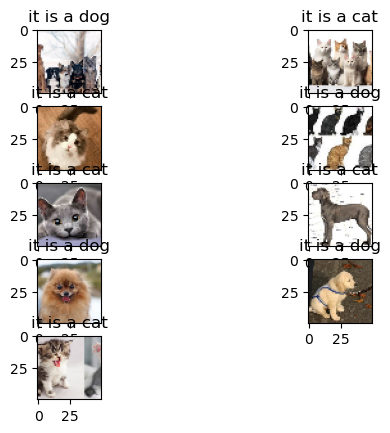

In [11]:
# plot the unlabeled image with predicted results
figure=plt.figure()
i=int(1)
row = int(len(ImgFromInternet)/2+(len(ImgFromInternet)%2>0))
for image in ImgFromInternetPreProcd:
    pred = TrainedCNNModle.predict(tf.expand_dims(image, axis=0),verbose=0)
    pred = (pred>0.5).astype(int)    
    plt.subplot(row,2,i)
    plt.imshow((image.numpy()*255).astype("uint8"))
    plt.title(f'it is a {"dog" if pred==1 else "cat"}')
    i += 1
plt.show()